[*********************100%***********************]  3 of 3 completed


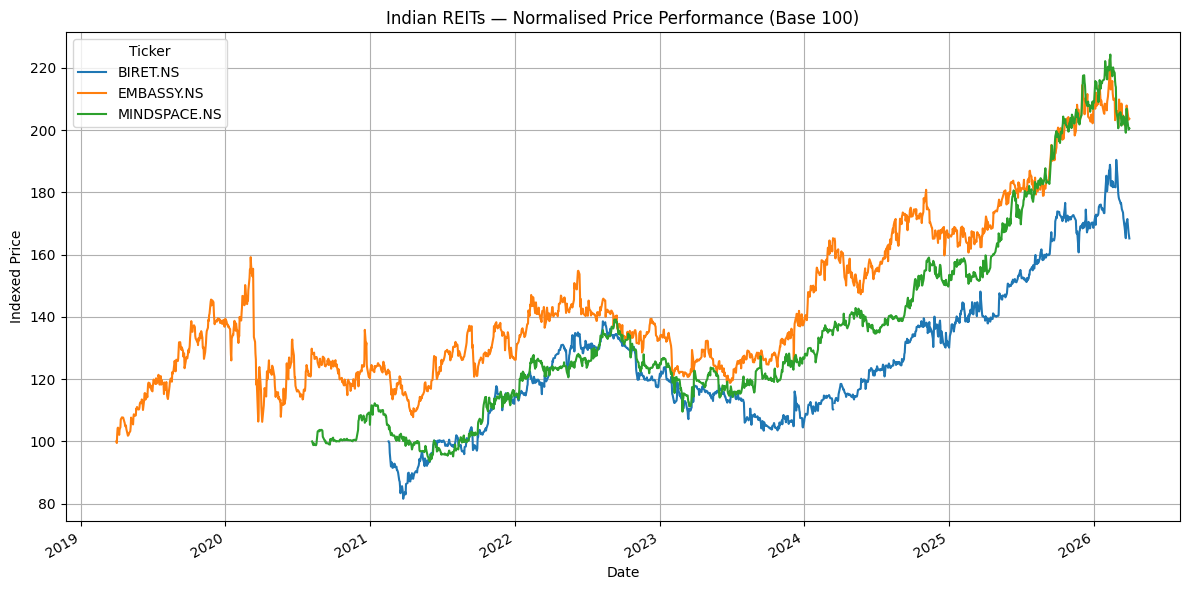

In [3]:
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ["EMBASSY.NS", "MINDSPACE.NS", "BIRET.NS"]
data = yf.download(tickers, start="2019-04-01")["Close"]

# Normalise to 100 at first available price
normalised = data.div(data.bfill().iloc[0]).mul(100)

normalised.plot(figsize=(12, 6), title="Indian REITs — Normalised Price Performance (Base 100)")
plt.ylabel("Indexed Price")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import pandas as pd

# Calculate weekly returns
weekly = data.resample('W').last().pct_change().dropna()

# Annualised metrics
trading_weeks = 52
rf_rate = 0.065  # 6.5% risk-free rate (10Y G-Sec)

ann_return = weekly.mean() * trading_weeks
ann_vol = weekly.std() * np.sqrt(trading_weeks)
sharpe = (ann_return - rf_rate) / ann_vol

metrics = pd.DataFrame({
    'Annualised Return': (ann_return * 100).round(2).astype(str) + '%',
    'Annualised Volatility': (ann_vol * 100).round(2).astype(str) + '%',
    'Sharpe Ratio': sharpe.round(2)
})

print(metrics)

             Annualised Return Annualised Volatility  Sharpe Ratio
Ticker                                                            
BIRET.NS                11.75%                15.74%          0.33
EMBASSY.NS              11.49%                16.94%          0.29
MINDSPACE.NS            13.74%                13.69%          0.53


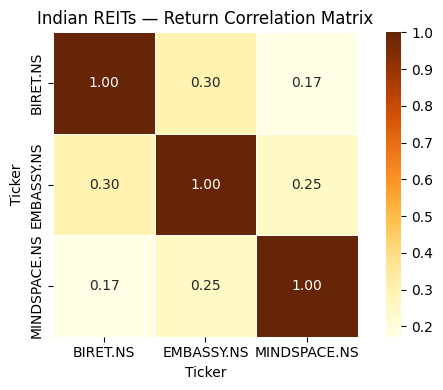

In [5]:
import seaborn as sns

corr = weekly.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrBr", 
            linewidths=0.5, square=True)
plt.title("Indian REITs — Return Correlation Matrix")
plt.tight_layout()
plt.show()

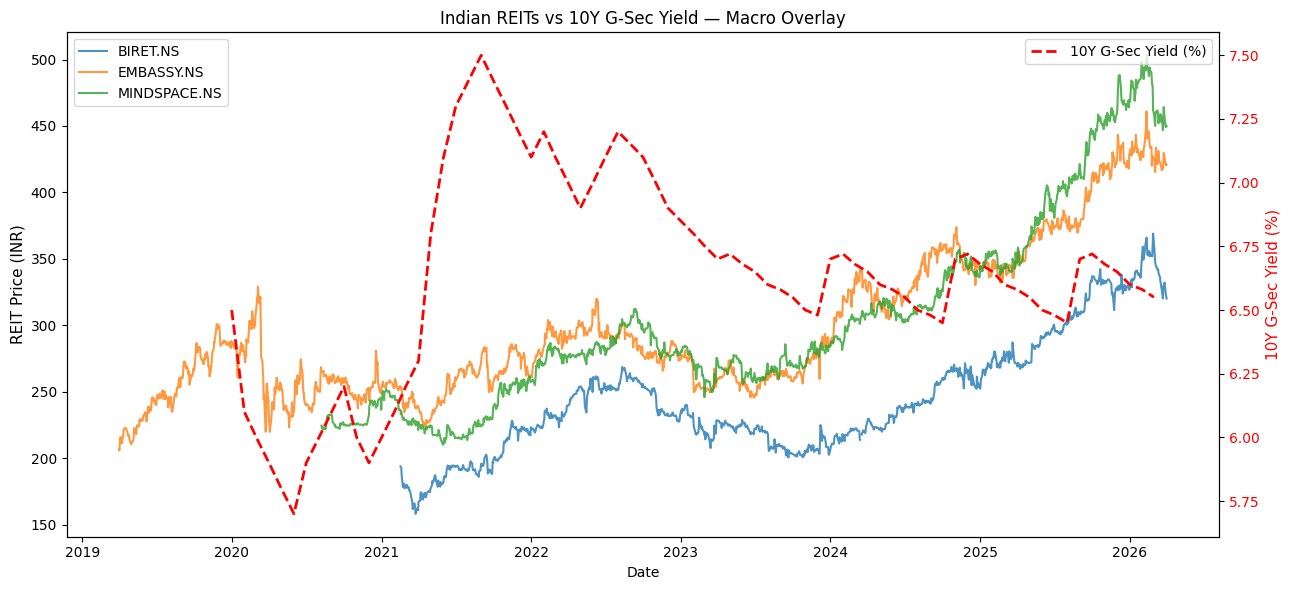

In [6]:
# Manual 10Y G-Sec yield data (RBI) — monthly approximations
gsec_dates = pd.date_range(start="2020-01-01", end="2026-03-01", freq="MS")
gsec_yields = [
    6.5, 6.1, 6.0, 5.9, 5.8, 5.7, 5.9, 6.0, 6.1, 6.2, 6.0, 5.9,
    6.0, 6.1, 6.2, 6.3, 6.8, 7.1, 7.3, 7.4, 7.5, 7.4, 7.3, 7.2,
    7.1, 7.2, 7.1, 7.0, 6.9, 7.0, 7.1, 7.2, 7.15, 7.1, 7.0, 6.9,
    6.85, 6.8, 6.75, 6.7, 6.72, 6.68, 6.65, 6.6, 6.58, 6.55, 6.5, 6.48,
    6.7, 6.72, 6.68, 6.65, 6.6, 6.58, 6.55, 6.5, 6.48, 6.45, 6.7, 6.72,
    6.68, 6.65, 6.6, 6.58, 6.55, 6.5, 6.48, 6.45, 6.7, 6.72, 6.68, 6.65,
    6.6, 6.58, 6.55
]

gsec = pd.Series(gsec_yields[:len(gsec_dates)], index=gsec_dates)

# Plot
fig, ax1 = plt.subplots(figsize=(13, 6))

for col in data.columns:
    ax1.plot(data.index, data[col], label=col, alpha=0.8)

ax1.set_ylabel("REIT Price (INR)", fontsize=11)
ax1.set_xlabel("Date")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(gsec.index, gsec.values, color="red", linewidth=2, 
         linestyle="--", label="10Y G-Sec Yield (%)")
ax2.set_ylabel("10Y G-Sec Yield (%)", color="red", fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc="upper right")

plt.title("Indian REITs vs 10Y G-Sec Yield — Macro Overlay")
plt.tight_layout()
plt.show()

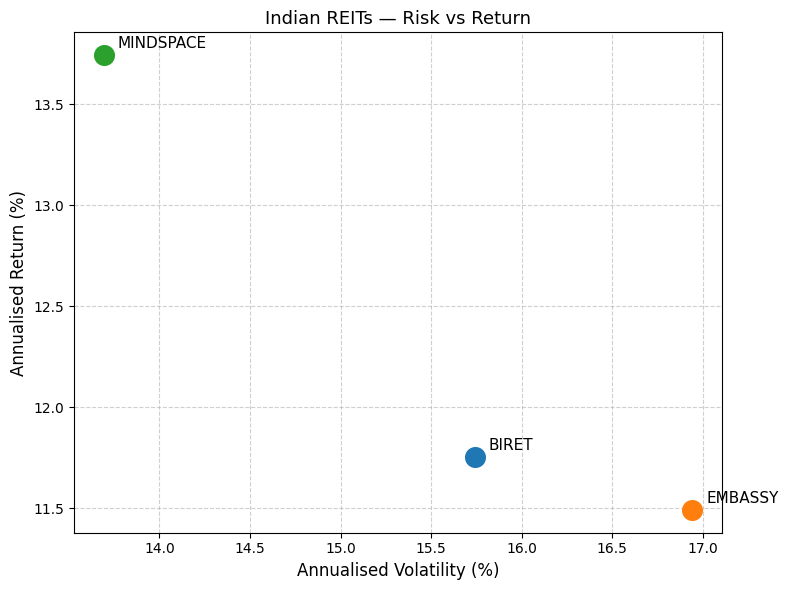

In [7]:
ann_ret = weekly.mean() * 52 * 100
ann_v = weekly.std() * np.sqrt(52) * 100

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, ticker in enumerate(ann_ret.index):
    ax.scatter(ann_v[ticker], ann_ret[ticker], s=200, 
               color=colors[i], zorder=5)
    ax.annotate(ticker.replace(".NS", ""), 
                (ann_v[ticker], ann_ret[ticker]),
                textcoords="offset points", xytext=(10, 5), fontsize=11)

ax.set_xlabel("Annualised Volatility (%)", fontsize=12)
ax.set_ylabel("Annualised Return (%)", fontsize=12)
ax.set_title("Indian REITs — Risk vs Return", fontsize=13)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Indian REITs — Analyst Commentary
*Data as of April 2026 | Analysis by Shashank Shekhar*

---

## Mindspace Business Parks (MINDSPACE.NS)
By far mindspace turns out to be the best performer in a India listed REIT universe. 
risk-adjusted basis, which is providing annualised returns of approximately 13.7 at the minimum volatility. 
of the three (13.7%). In its turn, Sharpe Ratio of 0.53 nearly twice that of Embassy indicates. 
the quality of its Hyderabad and Mumbai asset base, high occupancy and a tenant. 
mix with high concentration on global technology captives having long lease contracts. Its low 
its association with peers (0.17 -0.25) adds to its argument as a core portfolio. 
holding. To an investor who would want constant and accretive real estate exposure, 
The most obvious purchase in the universe is mindspace.

---

## Brookfield India REIT (BIRET.NS)
Brookfield is in the intermediate ground (moderate returns: 11.75 and contained). 
volatility (15.7%) and a Sharpe of 0.33. Being the latest of the three listings, it 
advantages of an institutionally run portfolio, mostly sponsored by Brookfield. 
concentrated to Mumbai, Gurugram and Noida. Its less correlation with Mindspace. 
(0.17) makes it a useful diversifier. The weakness is that it has a relatively shorter track which is the key risk. 
concentration of record and sponsor. The portfolio matures and it is distributions season. 
Brookfield can narrow down the risk-adjusted returns between Brookfield and Mindspace.

---

## Embassy Office Parks (EMBASSY.NS)
The youngest and largest Indian REIT, Embassy is, of course, the weakest. 
risk-adjusted performance - the maximum volatility (16.9%), the minimum Sharpe (0.29) 
of the three. Although it has scale through its portfolio held by Bangalore and its hotel assets, 
they also labor to bring about sector and geographic concentration risk. The data suggests 
These risks have become more algorithmized in the market. Embassy will be applicable to 
pure return-seeking to index, desired as an exposure to the index and the need to access liquidity. 
Mindspace is more beneficial to the investors until Embassy proves to be a credible investor. 
re-rating catalyst.

---

## Macro Risk Flag
The three REITs were sensitive to the 20212022 G-Sec yield spike with prices. 
slow or falling down to the 10Y yield of around 7.5%. With yields currently 
bending to 6.56.6, the macro environment is becoming favorable to REIT. 
valuations. But reversal as impetus by world rates pressure or RBI policy. 
shift is the major systematic risk to the overall asset class.


